# Testing our equation to La Jara data 

In [47]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error

### Model Functions

τ*c evolution - transport capacity (tc)

In [48]:
def evolve_tauc_tc(
    tau_star,           # array of Shields stress τ*(t)
    dt,                 # timestep between τ* samples (15 minutes in my case)
    tau_c_min,          # minimum τ*c global
    tau_c_max,          # maximum τ*c global
    event_indices,      # time labels or integer positions where τ*c observations are available
    tau_c_obs,          # observed τ*c values at event_indices
    A = 0.2924,
    B = 8.6866,
    ks = 50,
    kw = 3.7,
    xs = 0.79
):

    # convert τ* to numeric 1D array and keep index if Series
    if isinstance(tau_star, pd.Series):
        tau_index = tau_star.index
        tau_star_vals = tau_star.to_numpy(dtype=float)
    else:
        tau_index = None
        tau_star_vals = np.asarray(tau_star, dtype=float)

    if tau_star_vals.ndim != 1:
        raise ValueError("tau_star must be 1D after conversion")

    # convert event indices to integer positions in tau_star_vals
    event_labels = np.asarray(event_indices)
    if tau_index is not None:
        event_pos = tau_index.get_indexer(event_labels)

        # allow an initialization observation before forcing starts (e.g., event 0 while tau index starts at 1)
        missing_mask = event_pos < 0
        if np.any(missing_mask) and np.issubdtype(event_labels.dtype, np.number):
            before_start = missing_mask & (event_labels < tau_index.min())
            event_pos[before_start] = 0

        if np.any(event_pos < 0):
            missing_labels = event_labels[event_pos < 0]
            raise ValueError(f"some event indices are not in tau_star index: {missing_labels}")
    else:
        event_pos = np.asarray(event_indices, dtype=int)

    # keep only observed τ*c values that are not NaN
    tau_c_obs_arr = np.asarray(tau_c_obs, dtype=float)
    valid_obs_mask = ~np.isnan(tau_c_obs_arr)
    event_pos_valid = event_pos[valid_obs_mask]
    tau_c_obs_valid = tau_c_obs_arr[valid_obs_mask]

    # initialize modeled τ*c, τ*c_eq, and k array
    n = len(tau_star_vals)
    tau_c = np.full(n, np.nan, dtype=float)  # nan means τ*c is undefined (e.g., during gaps)
    tau_c_pot = np.full(n, np.nan, dtype=float)
    k_array = np.full(n, np.nan, dtype=float)
    tauc_ratio = np.full(n, np.nan, dtype=float)
    tau_conv_array = np.full(n, np.nan, dtype=float)

    tau_c_obs_dict = dict(zip(event_pos_valid, tau_c_obs_valid))
    was_in_gap = True

    i = 0
    while i < n-1:
        # determine current τ*
        t = tau_star_vals[i]  # current τ*

        # k equation parameters from flume data
        k = A * (t / tau_c_max) ** B

        # initialize τ*c when observation exists
        if was_in_gap and i in tau_c_obs_dict:
            tau_c_current = tau_c_obs_dict[i]
            tau_c[i] = tau_c_current
            was_in_gap = False
        else:
            tau_c_current = tau_c[i]

        # calculate transport capacity 
        tc = t/tau_c_current  # transport capacity
        tauc_ratio[i] = tc

        # calculate potential τ*c based on current τ*/τ*c
        if tc <= 1:
            sigmoid_0 = 1 / (1 + np.exp(-ks * (0 - xs)))
            sigmoid_1 = 1 / (1 + np.exp(-ks * (1 - xs)))
            sigmoig_tc = 1 / (1 + np.exp(-ks * (tc - xs)))
            sigmoid = (sigmoig_tc - sigmoid_0) / (sigmoid_1 - sigmoid_0)
            tau_conv = tau_c_min + (tau_c_max - tau_c_min) * sigmoid 
            tau_pot = max(tau_c_current, tau_conv)  # τ*c cannot decrease below current value if τ* is low
            tau_pot_pure = tau_conv
        else:  # otherwise, equilibrium is given by the weakening function
            tau_conv = tau_c_min + (tau_c_max - tau_c_min) * (tc) ** (-kw)
            tau_pot = tau_conv
            tau_pot_pure = tau_conv

        k_array[i] = k
        tau_c_pot[i] = tau_pot_pure
        tau_conv_array[i] = tau_pot

        # evolve τ*c with new equation
        tau_c[i+1] = tau_conv_array[i] - (tau_conv_array[i] - tau_c[i]) * np.exp(-k * dt)
        #print('tauc at time:', i, 'is', tau_c[i], '. tau/tauc', tauc_ratio[i], 'and tau_pot is', tau_c_pot[i], 'with k', k_array[i])
        i += 1

    return tau_c, k_array, tau_c_pot, tauc_ratio

### Testing Field Data

Import Data

In [49]:
# import data 
tau_star = pd.read_csv('data/average_shear_stress_lajara_full.csv')
tauc_events = pd.read_csv('data/tauc_events_exceedance_rising.csv', parse_dates=['datetime'], index_col='datetime')
# convert to datetime and set as index
tau_star['datetime'] = pd.to_datetime(tau_star['datetime']) 
tau_star = tau_star.set_index('datetime')

df_tau_resampled = tau_star.resample('1min').ffill()  # forwardfill to keep tau* constant during gaps
# create continuous 1-minute time index from first timestamp to last
continuous_index = pd.date_range(start=tau_star.index.min(), end=tau_star.index.max(), freq='1min')

# change column name to 'tau' for clarity
df_tau_resampled = df_tau_resampled.rename(columns={'shear_stress': 'tau'})
# delete everything before 2022-07-14 (we don't care about earlier times)
df_tau_resampled = df_tau_resampled[df_tau_resampled.index >= '2022-07-14 15:00']

print(f"Data gaps (NaNs): {df_tau_resampled['tau'].isna().sum().sum()}")
# show what dates are the data gaps
print("Data gaps (NaN indices):", df_tau_resampled[df_tau_resampled['tau'].isna()].index)

# convert tau to dimenstionless Shields stress τ*
rho_s = 2650.0  # sediment density, kg/m3
rho = 1000.0   # fluid density, kg/m3
g = 9.81       # gravitational acceleration, m/s2
d50 = 0.04364    # median grain diameter, m

df_tau_resampled['tau_star'] = df_tau_resampled['tau'] / ((rho_s - rho) * g * d50)

# build integer index mapping
time_to_index = pd.Series(
    np.arange(len(df_tau_resampled)), 
    index=df_tau_resampled.index
)
event_indices = time_to_index.loc[tauc_events.index].to_numpy() # integer indices of event times
tau_c_obs = tauc_events["tauc"].to_numpy() # observed τ*c values
tau_star = df_tau_resampled["tau_star"].to_numpy() # τ* time series array

# calculate dt in minutes (should be 15)
dt = (df_tau_resampled.index[1] - df_tau_resampled.index[0]).total_seconds() / 60
print(f"Calculated dt: {dt} minutes")

Data gaps (NaNs): 0
Data gaps (NaN indices): DatetimeIndex([], dtype='datetime64[ns]', name='datetime', freq='min')
Calculated dt: 1.0 minutes


## 1a) Min-Max: Measured; k: Flume

MAE (observed vs predicted tau_c* at event times): 0.0219


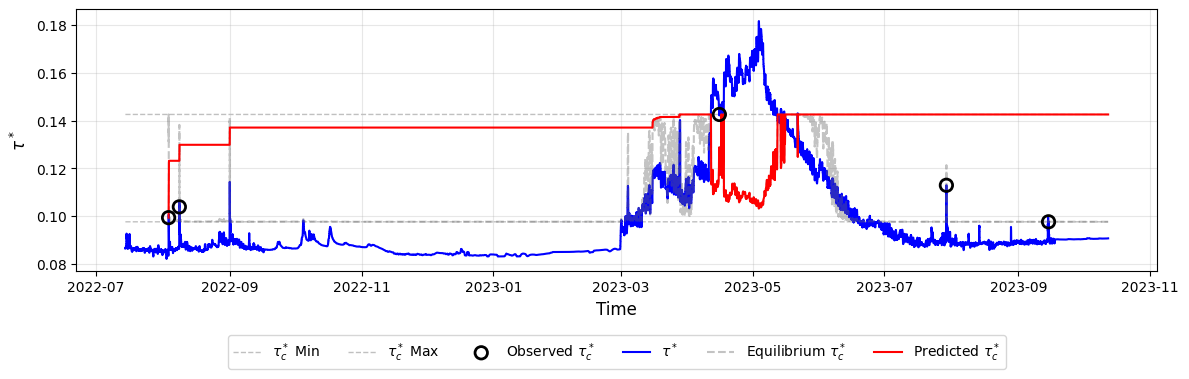

In [50]:
tauc_obs_lajara = tauc_events["tauc"].to_numpy()
# find min and max of τ*c observations to set bounds for model
tauc_min_lajara = tauc_obs_lajara.min() 
tauc_max_lajara = tauc_obs_lajara.max()

tauc_lajara, k_lajara, tau_eq_lajara, tauc_ratio_field = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=tauc_min_lajara,
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
)
tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

# calculate MAE between observed and predicted tau_c* at event timestamps
common_idx = tauc_events.index.intersection(tau_c_pred_series.index)
tauc_obs_at_events = tauc_events.loc[common_idx, "tauc"]
tauc_pred_at_events = tau_c_pred_series.reindex(common_idx)
valid_mask = tauc_obs_at_events.notna() & tauc_pred_at_events.notna()

if valid_mask.any():
    mae_tauc = mean_absolute_error(tauc_obs_at_events[valid_mask], tauc_pred_at_events[valid_mask])
    print(f"MAE (observed vs predicted tau_c* at event times): {mae_tauc:.4f}")
else:
    print("MAE could not be computed: no overlapping valid observed/predicted tau_c* values.")


fig, ax = plt.subplots(figsize=(12, 4))
# horiztonal min and max lines 
ax.plot(tau_c_pred_series.index, [tauc_min_lajara]*len(tau_c_pred_series), color='silver', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='silver', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
ax.scatter(tauc_events.index, tauc_obs_lajara, facecolors="none", edgecolors="black", s=80, linewidth=2, label=r"Observed $\tau^*_c$", zorder=5,)

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_star_series.index, tau_eq_lajara, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5, alpha=0.4)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=6)
ax.grid(True, alpha=0.3)

#plt.title(r'Using $\tau^*$/$\tau_c^*$ balance equation', fontsize=14)
# modify dates on x-axis to be more readable
#plt.xlim(pd.Timestamp("2023-07-20"), pd.Timestamp("2023-08-05"))
plt.tight_layout()
plt.show()

## 1b) Min-Max: Measured; k: Calibrated A&B

MAE (observed vs predicted tau_c* at event times): 0.0105


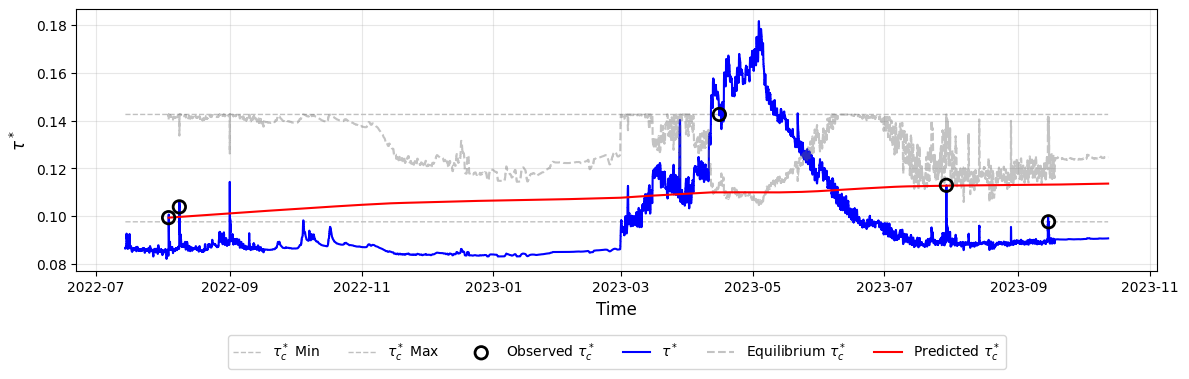

In [51]:
tauc_lajara, k_lajara, tau_eq_lajara, tauc_ratio_field = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=tauc_min_lajara,
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=1.747528400007683e-06,
    B=1
)
tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

# calculate MAE between observed and predicted tau_c* at event timestamps
common_idx = tauc_events.index.intersection(tau_c_pred_series.index)
tauc_obs_at_events = tauc_events.loc[common_idx, "tauc"]
tauc_pred_at_events = tau_c_pred_series.reindex(common_idx)
valid_mask = tauc_obs_at_events.notna() & tauc_pred_at_events.notna()

if valid_mask.any():
    mae_tauc = mean_absolute_error(tauc_obs_at_events[valid_mask], tauc_pred_at_events[valid_mask])
    print(f"MAE (observed vs predicted tau_c* at event times): {mae_tauc:.4f}")
else:
    print("MAE could not be computed: no overlapping valid observed/predicted tau_c* values.")

fig, ax = plt.subplots(figsize=(12, 4))
# horiztonal min and max lines 
ax.plot(tau_c_pred_series.index, [tauc_min_lajara]*len(tau_c_pred_series), color='silver', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='silver', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
ax.scatter(tauc_events.index, tauc_obs_lajara, facecolors="none", edgecolors="black", s=80, linewidth=2, label=r"Observed $\tau^*_c$", zorder=5,)

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_star_series.index, tau_eq_lajara, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5, alpha=0.4)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=6)
ax.grid(True, alpha=0.3)

#plt.title(r'Using $\tau^*$/$\tau_c^*$ balance equation', fontsize=14)
# modify dates on x-axis to be more readable
#plt.xlim(pd.Timestamp("2023-07-20"), pd.Timestamp("2023-08-05"))
plt.tight_layout()
plt.show()

## 1c) Min-Max: Measured; k and tau_eq Calibrated

MAE (observed vs predicted tau_c* at event times): 0.0087


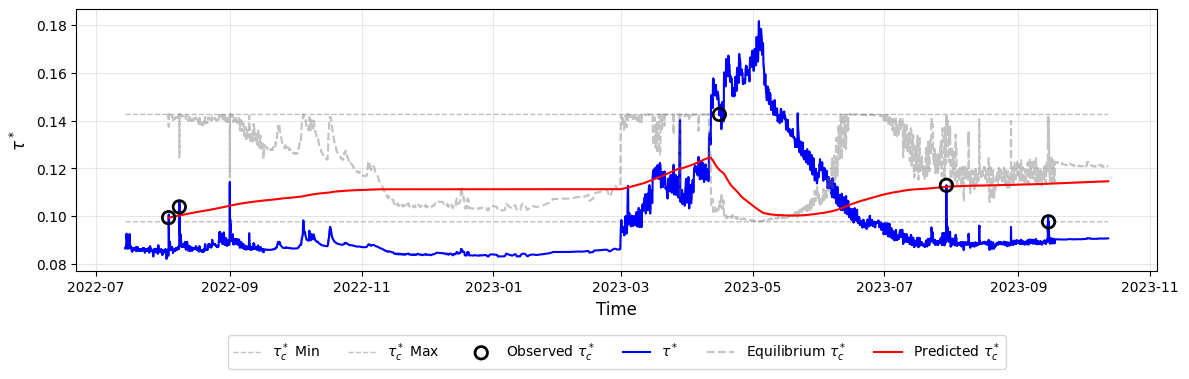

In [52]:
tauc_lajara, k_lajara, tau_eq_lajara, tauc_ratio_field = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=tauc_min_lajara,
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=0.0000359381366380462,
    B=5.03968419957949, 
    ks=50,
    kw=9.526315789
)
tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

# calculate MAE between observed and predicted tau_c* at event timestamps
common_idx = tauc_events.index.intersection(tau_c_pred_series.index)
tauc_obs_at_events = tauc_events.loc[common_idx, "tauc"]
tauc_pred_at_events = tau_c_pred_series.reindex(common_idx)
valid_mask = tauc_obs_at_events.notna() & tauc_pred_at_events.notna()

if valid_mask.any():
    mae_tauc = mean_absolute_error(tauc_obs_at_events[valid_mask], tauc_pred_at_events[valid_mask])
    print(f"MAE (observed vs predicted tau_c* at event times): {mae_tauc:.4f}")
else:
    print("MAE could not be computed: no overlapping valid observed/predicted tau_c* values.")

fig, ax = plt.subplots(figsize=(12, 4))
# horiztonal min and max lines 
ax.plot(tau_c_pred_series.index, [tauc_min_lajara]*len(tau_c_pred_series), color='silver', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='silver', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
ax.scatter(tauc_events.index, tauc_obs_lajara, facecolors="none", edgecolors="black", s=80, linewidth=2, label=r"Observed $\tau^*_c$", zorder=5,)

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_star_series.index, tau_eq_lajara, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5, alpha=0.4)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=6)
ax.grid(True, alpha=0.3)

#plt.title(r'Using $\tau^*$/$\tau_c^*$ balance equation', fontsize=14)
# modify dates on x-axis to be more readable
#plt.xlim(pd.Timestamp("2023-07-20"), pd.Timestamp("2023-08-05"))
plt.tight_layout()
plt.show()

## Figure 1

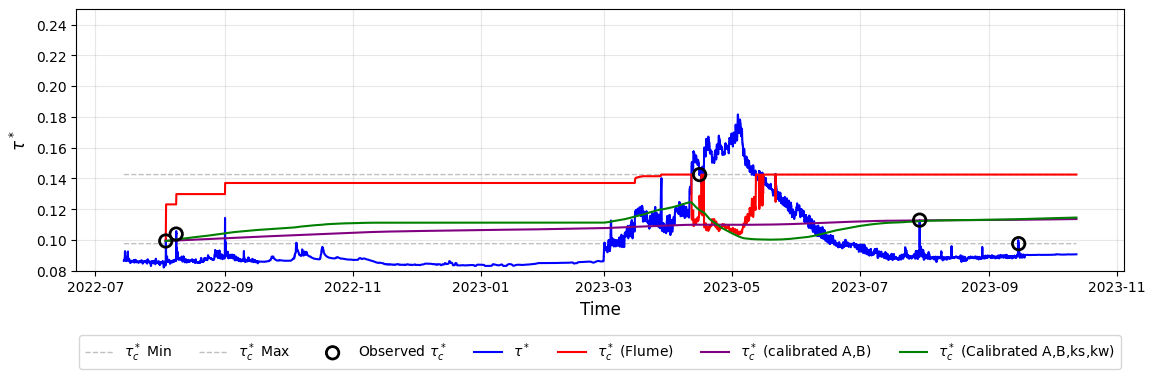

In [53]:
tau_star_series = pd.Series(tau_star, index=time_to_index.index)
# (a)
tauc_lajara1, k_lajara1, tau_eq_lajara1, tauc_ratio_field1 = evolve_tauc_tc(tau_star, dt=1, tau_c_min=tauc_min_lajara, tau_c_max=tauc_max_lajara, 
event_indices=event_indices, tau_c_obs=tauc_obs_lajara)
tau_c_pred_series1 = pd.Series(tauc_lajara1, index=time_to_index.index)

# (b)
tauc_lajara2, k_lajara2, tau_eq_lajara2, tauc_ratio_field2 = evolve_tauc_tc(tau_star, dt=1, tau_c_min=tauc_min_lajara, tau_c_max=tauc_max_lajara, 
event_indices=event_indices, tau_c_obs=tauc_obs_lajara, A=1.747528400007683e-06, B=1)
tau_c_pred_series2 = pd.Series(tauc_lajara2, index=time_to_index.index)

# (c)
tauc_lajara3, k_lajara3, tau_eq_lajara3, tauc_ratio_field3 = evolve_tauc_tc(tau_star, dt=1, tau_c_min=tauc_min_lajara, tau_c_max=tauc_max_lajara, 
event_indices=event_indices, tau_c_obs=tauc_obs_lajara, A=0.0000359381366380462, B=5.03968419957949,  ks=50, kw=9.526315789)
tau_c_pred_series3 = pd.Series(tauc_lajara3, index=time_to_index.index)


fig, ax = plt.subplots(figsize=(12, 4))
# horiztonal min and max lines 
ax.plot(tau_c_pred_series1.index, [tauc_min_lajara]*len(tau_c_pred_series1), color='silver', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series1.index, [tauc_max_lajara]*len(tau_c_pred_series1), color='silver', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
ax.scatter(tauc_events.index, tauc_obs_lajara, facecolors="none", edgecolors="black", s=80, linewidth=2, label=r"Observed $\tau^*_c$", zorder=5,)

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5) # applied tau* time series
ax.plot(tau_c_pred_series1.index, tau_c_pred_series1.values, color='red', label=r'$\tau_c^*$ (Flume)', linewidth=1.5) # (a)
ax.plot(tau_c_pred_series2.index, tau_c_pred_series2.values, color='purple', label=r'$\tau_c^*$ (calibrated A,B)', linewidth=1.5) # (b)
ax.plot(tau_c_pred_series3.index, tau_c_pred_series3.values, color='green', label=r'$\tau_c^*$ (Calibrated A,B,ks,kw)', linewidth=1.5) # (c)


ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_ylim(0.08, 0.25)
ax.set_xlabel('Time', fontsize=12)
ax.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=7)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 2a) Min-Max: Slope; k: Flume

MAE (observed vs predicted tau_c* at event times): 0.0597


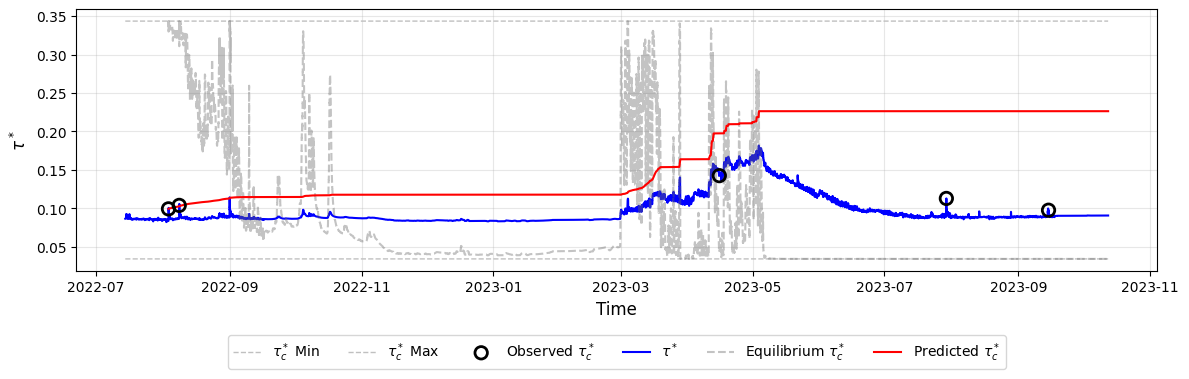

In [54]:
tauc_obs_lajara = tauc_events["tauc"].to_numpy()
tauc_min_lajara_slope = 0.0343
tauc_max_lajara_slope = 0.3435

tauc_lajara, k_lajara, tau_eq_lajara, tauc_ratio_field = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=tauc_min_lajara_slope,
    tau_c_max=tauc_max_lajara_slope,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
)
tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

# calculate MAE between observed and predicted tau_c* at event timestamps
common_idx = tauc_events.index.intersection(tau_c_pred_series.index)
tauc_obs_at_events = tauc_events.loc[common_idx, "tauc"]
tauc_pred_at_events = tau_c_pred_series.reindex(common_idx)
valid_mask = tauc_obs_at_events.notna() & tauc_pred_at_events.notna()

if valid_mask.any():
    mae_tauc = mean_absolute_error(tauc_obs_at_events[valid_mask], tauc_pred_at_events[valid_mask])
    print(f"MAE (observed vs predicted tau_c* at event times): {mae_tauc:.4f}")
else:
    print("MAE could not be computed: no overlapping valid observed/predicted tau_c* values.")


fig, ax = plt.subplots(figsize=(12, 4))
# horiztonal min and max lines 
ax.plot(tau_c_pred_series.index, [tauc_min_lajara_slope]*len(tau_c_pred_series), color='silver', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara_slope]*len(tau_c_pred_series), color='silver', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
ax.scatter(tauc_events.index, tauc_obs_lajara, facecolors="none", edgecolors="black", s=80, linewidth=2, label=r"Observed $\tau^*_c$", zorder=5,)

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_star_series.index, tau_eq_lajara, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5, alpha=0.4)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=6)
ax.grid(True, alpha=0.3)

#plt.title(r'Using $\tau^*$/$\tau_c^*$ balance equation', fontsize=14)
# modify dates on x-axis to be more readable
#plt.xlim(pd.Timestamp("2023-07-20"), pd.Timestamp("2023-08-05"))
plt.tight_layout()
plt.show()

## 2b) Min-Max: Slope; k: Calibrated A&B

MAE (observed vs predicted tau_c* at event times): 0.0106


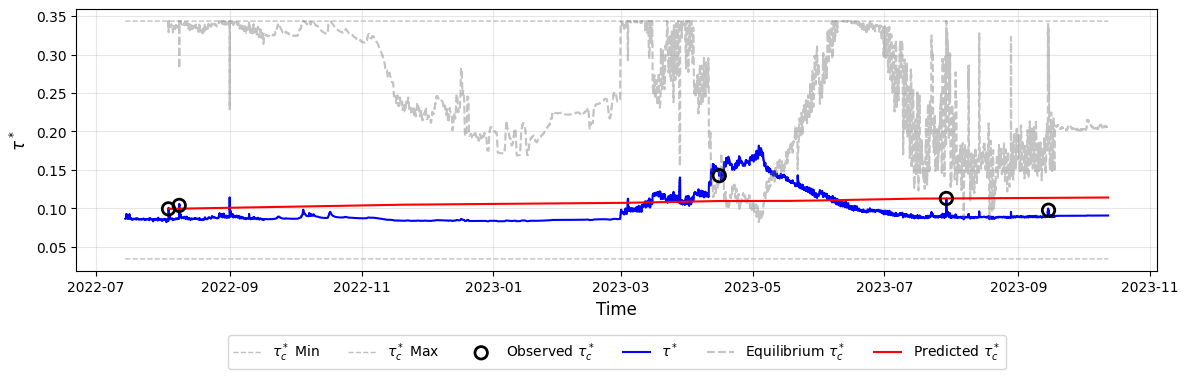

In [55]:
tauc_obs_lajara = tauc_events["tauc"].to_numpy()

tauc_lajara, k_lajara, tau_eq_lajara, tauc_ratio_field = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=tauc_min_lajara_slope,
    tau_c_max=tauc_max_lajara_slope,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=1e-06,
    B=1.3673469387755102
)
tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

# calculate MAE between observed and predicted tau_c* at event timestamps
common_idx = tauc_events.index.intersection(tau_c_pred_series.index)
tauc_obs_at_events = tauc_events.loc[common_idx, "tauc"]
tauc_pred_at_events = tau_c_pred_series.reindex(common_idx)
valid_mask = tauc_obs_at_events.notna() & tauc_pred_at_events.notna()

if valid_mask.any():
    mae_tauc = mean_absolute_error(tauc_obs_at_events[valid_mask], tauc_pred_at_events[valid_mask])
    print(f"MAE (observed vs predicted tau_c* at event times): {mae_tauc:.4f}")
else:
    print("MAE could not be computed: no overlapping valid observed/predicted tau_c* values.")


fig, ax = plt.subplots(figsize=(12, 4))
# horiztonal min and max lines 
ax.plot(tau_c_pred_series.index, [tauc_min_lajara_slope]*len(tau_c_pred_series), color='silver', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara_slope]*len(tau_c_pred_series), color='silver', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
ax.scatter(tauc_events.index, tauc_obs_lajara, facecolors="none", edgecolors="black", s=80, linewidth=2, label=r"Observed $\tau^*_c$", zorder=5,)

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_star_series.index, tau_eq_lajara, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5, alpha=0.4)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=6)
ax.grid(True, alpha=0.3)

#plt.title(r'Using $\tau^*$/$\tau_c^*$ balance equation', fontsize=14)
# modify dates on x-axis to be more readable
#plt.xlim(pd.Timestamp("2023-07-20"), pd.Timestamp("2023-08-05"))
plt.tight_layout()
plt.show()

## 2c) Min-Max: Slope; k and tau_eq Calibrated

MAE (observed vs predicted tau_c* at event times): 0.0054


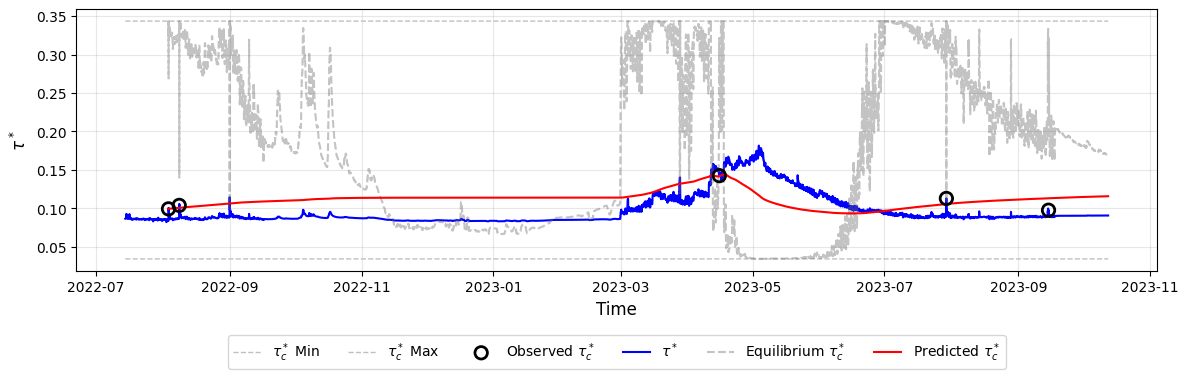

In [56]:
tauc_lajara, k_lajara, tau_eq_lajara, tauc_ratio_field = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=tauc_min_lajara_slope,
    tau_c_max=tauc_max_lajara_slope,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=0.00046415888336127773,
    B=4.641588833612778, 
    ks=35.93813663804626,
    kw=21.544346900318832
)
tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

# calculate MAE between observed and predicted tau_c* at event timestamps
common_idx = tauc_events.index.intersection(tau_c_pred_series.index)
tauc_obs_at_events = tauc_events.loc[common_idx, "tauc"]
tauc_pred_at_events = tau_c_pred_series.reindex(common_idx)
valid_mask = tauc_obs_at_events.notna() & tauc_pred_at_events.notna()

if valid_mask.any():
    mae_tauc = mean_absolute_error(tauc_obs_at_events[valid_mask], tauc_pred_at_events[valid_mask])
    print(f"MAE (observed vs predicted tau_c* at event times): {mae_tauc:.4f}")
else:
    print("MAE could not be computed: no overlapping valid observed/predicted tau_c* values.")

fig, ax = plt.subplots(figsize=(12, 4))
# horiztonal min and max lines 
ax.plot(tau_c_pred_series.index, [tauc_min_lajara_slope]*len(tau_c_pred_series), color='silver', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara_slope]*len(tau_c_pred_series), color='silver', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
ax.scatter(tauc_events.index, tauc_obs_lajara, facecolors="none", edgecolors="black", s=80, linewidth=2, label=r"Observed $\tau^*_c$", zorder=5,)

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_star_series.index, tau_eq_lajara, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5, alpha=0.4)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=6)
ax.grid(True, alpha=0.3)

#plt.title(r'Using $\tau^*$/$\tau_c^*$ balance equation', fontsize=14)
# modify dates on x-axis to be more readable
#plt.xlim(pd.Timestamp("2023-07-20"), pd.Timestamp("2023-08-05"))
plt.tight_layout()
plt.show()

## Figure 2

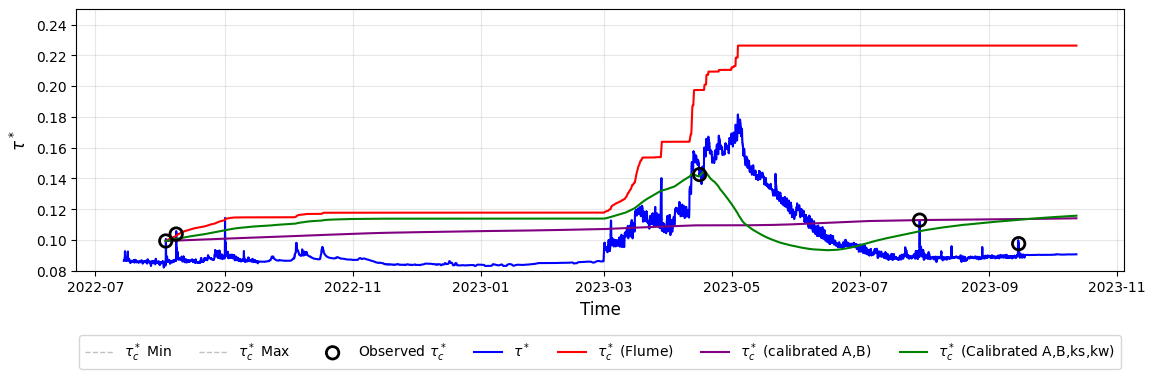

In [57]:
tau_star_series = pd.Series(tau_star, index=time_to_index.index)
# (a)
tauc_lajara4, k_lajara4, tau_eq_lajara4, tauc_ratio_field4 = evolve_tauc_tc(tau_star, dt=1, tau_c_min=tauc_min_lajara_slope, tau_c_max=tauc_max_lajara_slope, 
event_indices=event_indices, tau_c_obs=tauc_obs_lajara)
tau_c_pred_series4 = pd.Series(tauc_lajara4, index=time_to_index.index)

# (b)
tauc_lajara5, k_lajara5, tau_eq_lajara5, tauc_ratio_field5 = evolve_tauc_tc(tau_star, dt=1, tau_c_min=tauc_min_lajara_slope, tau_c_max=tauc_max_lajara_slope, 
event_indices=event_indices, tau_c_obs=tauc_obs_lajara, A=1e-06, B=1.3673469387755102)
tau_c_pred_series5 = pd.Series(tauc_lajara5, index=time_to_index.index)

# (c)
tauc_lajara6, k_lajara6, tau_eq_lajara6, tauc_ratio_field6 = evolve_tauc_tc(tau_star, dt=1, tau_c_min=tauc_min_lajara_slope, tau_c_max=tauc_max_lajara_slope, 
event_indices=event_indices, tau_c_obs=tauc_obs_lajara, A=0.00046415888336127773, B=4.641588833612778,  ks=35.93813663804626, kw=21.544346900318832)
tau_c_pred_series6 = pd.Series(tauc_lajara6, index=time_to_index.index)


fig, ax = plt.subplots(figsize=(12, 4))
# horiztonal min and max lines 
ax.plot(tau_c_pred_series4.index, [tauc_min_lajara_slope]*len(tau_c_pred_series4), color='silver', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series4.index, [tauc_max_lajara_slope]*len(tau_c_pred_series4), color='silver', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
ax.scatter(tauc_events.index, tauc_obs_lajara, facecolors="none", edgecolors="black", s=80, linewidth=2, label=r"Observed $\tau^*_c$", zorder=5,)

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5) # applied tau* time series
ax.plot(tau_c_pred_series4.index, tau_c_pred_series4.values, color='red', label=r'$\tau_c^*$ (Flume)', linewidth=1.5) # (a)
ax.plot(tau_c_pred_series5.index, tau_c_pred_series5.values, color='purple', label=r'$\tau_c^*$ (calibrated A,B)', linewidth=1.5) # (b)
ax.plot(tau_c_pred_series6.index, tau_c_pred_series6.values, color='green', label=r'$\tau_c^*$ (Calibrated A,B,ks,kw)', linewidth=1.5) # (c)


ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_ylim(0.08, 0.25)
ax.set_xlabel('Time', fontsize=12)
ax.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=7)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final Figure

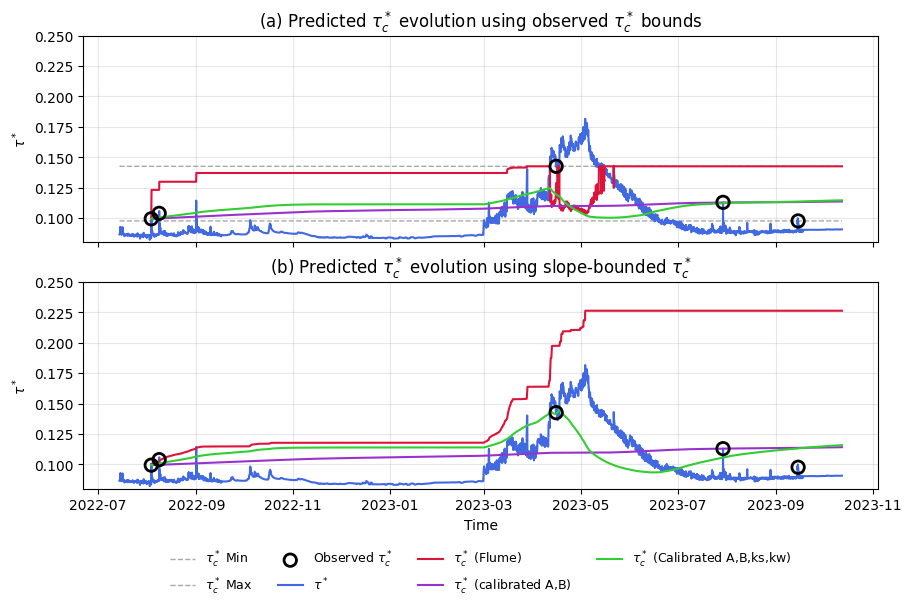

In [72]:
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(9, 6),
                        sharex=True, constrained_layout=True)

# top panel - our bounds of tc
tauc_min_lajara = tauc_obs_lajara.min() 
tauc_max_lajara = tauc_obs_lajara.max()

ax_top.plot(tau_c_pred_series1.index, [tauc_min_lajara] * len(tau_c_pred_series1),
    color='darkgray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax_top.plot(tau_c_pred_series1.index, [tauc_max_lajara] * len(tau_c_pred_series1),
    color='darkgray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
ax_top.scatter(tauc_events.index, tauc_obs_lajara, facecolors='none', edgecolors='black',
    s=80, linewidth=2, label=r'Observed $\tau^*_c$', zorder=5)
ax_top.plot(tau_star_series.index, tau_star_series.values, color='royalblue', label=r'$\tau^*$', linewidth=1.5)
ax_top.plot(tau_c_pred_series1.index, tau_c_pred_series1.values, color='crimson', label=r'$\tau_c^*$ (Flume)', linewidth=1.5)
ax_top.plot(tau_c_pred_series2.index, tau_c_pred_series2.values, color='darkorchid', label=r'$\tau_c^*$ (calibrated A,B)', linewidth=1.5)
ax_top.plot(tau_c_pred_series3.index, tau_c_pred_series3.values, color='limegreen', label=r'$\tau_c^*$ (Calibrated A,B,ks,kw)', linewidth=1.5)
ax_top.set_ylabel(r'$\tau^*$', fontsize=10)
ax_top.set_ylim(0.08, 0.25)
ax_top.grid(True, alpha=0.3)
ax_top.set_title(r'(a) Predicted $\tau_c^*$ evolution using observed $\tau_c^*$ bounds', fontsize=12)

# bottom pannel - slope bounded tc
tauc_min_lajara_slope = 0.0343
tauc_max_lajara_slope = 0.3435

ax_bottom.plot(tau_c_pred_series4.index, [tauc_min_lajara_slope] * len(tau_c_pred_series4),
    color='darkgray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax_bottom.plot(tau_c_pred_series4.index, [tauc_max_lajara_slope] * len(tau_c_pred_series4), 
    color='darkgray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
ax_bottom.scatter(tauc_events.index, tauc_obs_lajara, facecolors='none', edgecolors='black',
    s=80, linewidth=2, label=r'Observed $\tau^*_c$', zorder=5)
ax_bottom.plot(tau_star_series.index, tau_star_series.values, color='royalblue', label=r'$\tau^*$', linewidth=1.5)
ax_bottom.plot(tau_c_pred_series4.index, tau_c_pred_series4.values, color='crimson', label=r'$\tau_c^*$ (Flume)', linewidth=1.5)
ax_bottom.plot(tau_c_pred_series5.index, tau_c_pred_series5.values, color='darkorchid', label=r'$\tau_c^*$ (calibrated A,B)', linewidth=1.5)
ax_bottom.plot(tau_c_pred_series6.index, tau_c_pred_series6.values, color='limegreen', label=r'$\tau_c^*$ (Calibrated A,B,ks,kw)', linewidth=1.5)
ax_bottom.set_ylabel(r'$\tau^*$', fontsize=10)
ax_bottom.set_ylim(0.08, 0.25)
ax_bottom.set_xlabel('Time', fontsize=10)
ax_bottom.grid(True, alpha=0.3)
ax_bottom.set_title(r'(b) Predicted $\tau_c^*$ evolution using slope-bounded $\tau_c^*$', fontsize=12)
ax_bottom.legend(fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.24), ncol=4, frameon=False)


plt.show()